<a href="https://colab.research.google.com/github/baisesreevidya-sys/FUTURE_DS_01/blob/main/Task2_Customer_Retention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/ravenstack_subscriptions.csv')
df.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


In [ ]:
df.describe(include='all')

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
count,5000,5000,5000,486,5000,5000.000000,5000.000000,5000.000000,5000,5000,5000,5000,5000,5000
unique,5000,500,625,208,3,NaN,NaN,NaN,2,2,2,2,2,2
top,S-71fc3d,A-d4ac0e,2024-12-31,2024-12-31,Enterprise,NaN,NaN,NaN,False,False,False,False,monthly,True
freq,1,19,45,24,1723,NaN,NaN,NaN,4222,4471,4782,4514,2539,4005
mean,NaN,NaN,NaN,NaN,NaN,29.852000,2267.749400,27212.992800,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,23.089771,3421.375348,41056.504178,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,14.000000,285.000000,3420.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,24.000000,931.000000,11172.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,40.000000,2786.000000,33432.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
subscription_id,0
account_id,0
start_date,0
end_date,4514
plan_tier,0
seats,0
mrr_amount,0
arr_amount,0
is_trial,0
upgrade_flag,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
subscription_id,object
account_id,object
start_date,object
end_date,object
plan_tier,object
seats,int64
mrr_amount,int64
arr_amount,int64
is_trial,bool
upgrade_flag,bool


In [ ]:
# Churn Rate
churn_rate = df['churn_flag'].value_counts()

print(churn_rate)

churn_flag
False    4514
True      486
Name: count, dtype: int64


In [ ]:
# Customer Retention Rate
retention_rate = df['churn_flag'].value_counts(normalize=True) * 100

print(retention_rate)

churn_flag
False    90.28
True      9.72
Name: proportion, dtype: float64


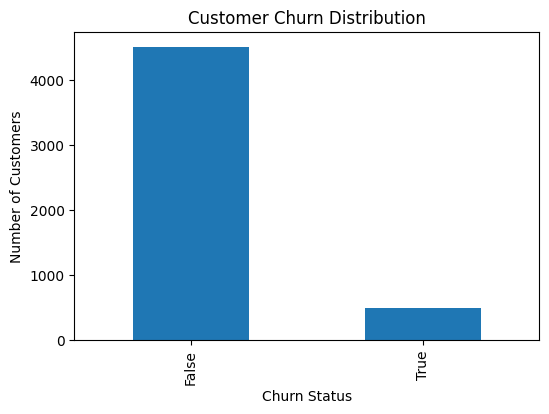

In [ ]:
# Churn Distribution
plt.figure(figsize=(6,4))
df['churn_flag'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Churn by Plan Tier
plan_churn = pd.crosstab(df['plan_tier'], df['churn_flag'])

print(plan_churn)

churn_flag  False  True 
plan_tier               
Basic        1450    152
Enterprise   1551    172
Pro          1513    162


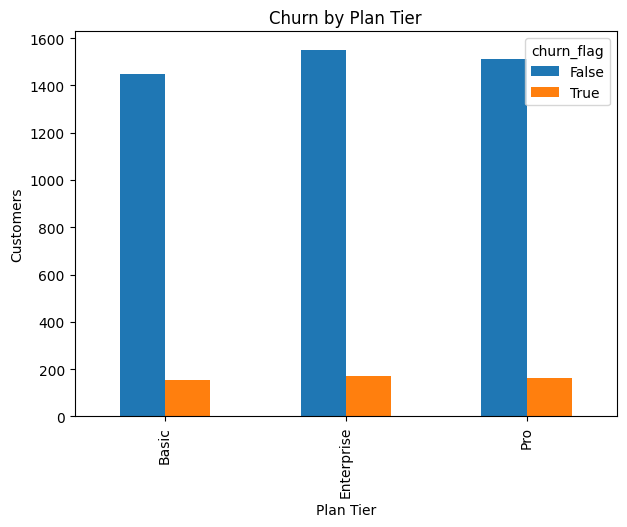

In [ ]:
# Churn by Plan Tier
plan_churn.plot(kind='bar', figsize=(7,5))

plt.title("Churn by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Customers")
plt.show()

In [ ]:
# Average Monthly Recurring Revenue (MRR) by Plan
mrr_plan = df.groupby('plan_tier')['mrr_amount'].mean()

print(mrr_plan)

plan_tier
Basic          474.679775
Enterprise    4917.713871
Pro           1256.769552
Name: mrr_amount, dtype: float64


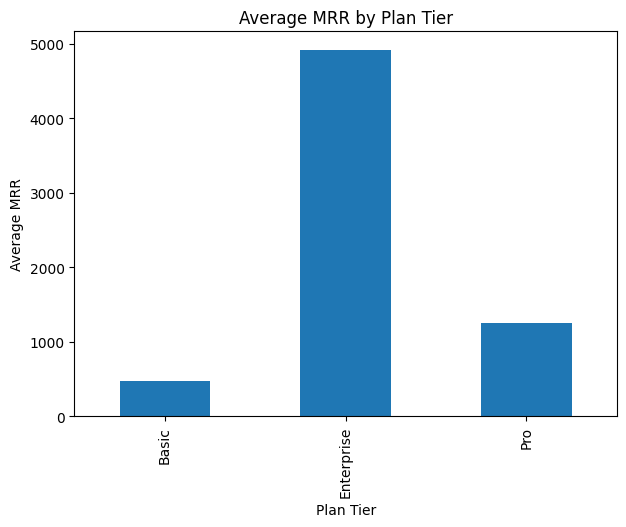

In [ ]:
# Average MRR by Plan Graph
plt.figure(figsize=(7,5))

mrr_plan.plot(kind='bar')

plt.title("Average MRR by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Average MRR")
plt.show()

In [ ]:
# Average Annual Recurring Revenue (ARR) by Plan
arr_plan = df.groupby('plan_tier')['arr_amount'].mean()

print(arr_plan)

plan_tier
Basic          5696.157303
Enterprise    59012.566454
Pro           15081.234627
Name: arr_amount, dtype: float64


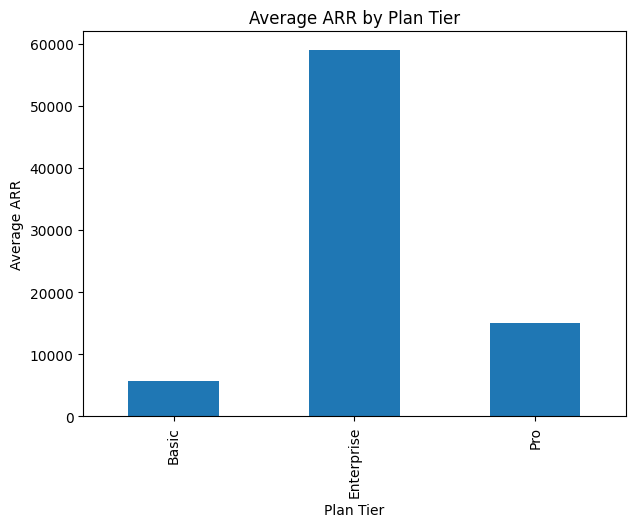

In [ ]:
# Average ARR by Plan Graph
plt.figure(figsize=(7,5))

arr_plan.plot(kind='bar')

plt.title("Average ARR by Plan Tier")
plt.xlabel("Plan Tier")
plt.ylabel("Average ARR")
plt.show()

In [ ]:
# Auto Renew Customers
auto_renew = df['auto_renew_flag'].value_counts()

print(auto_renew)

auto_renew_flag
True     4005
False     995
Name: count, dtype: int64


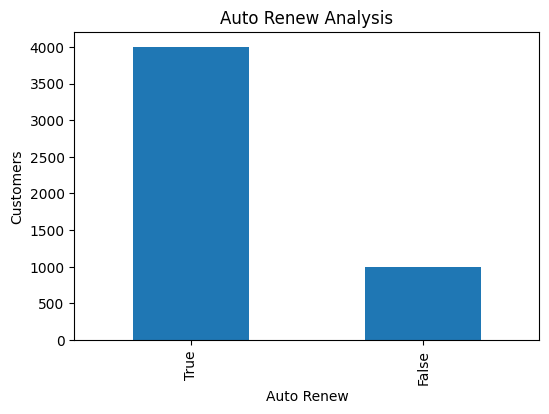

In [ ]:
# Auto Renew Graph
plt.figure(figsize=(6,4))

df['auto_renew_flag'].value_counts().plot(kind='bar')

plt.title("Auto Renew Analysis")
plt.xlabel("Auto Renew")
plt.ylabel("Customers")
plt.show()

In [ ]:
accounts = pd.read_csv('/content/ravenstack_accounts.csv')

accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [ ]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


In [ ]:
# Convert signup_date to datetime
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])

# Extract signup month
accounts['signup_month'] = accounts['signup_date'].dt.to_period('M')

signup_month = accounts['signup_month'].value_counts().sort_index()

print(signup_month)

signup_month
2023-01    17
2023-02    18
2023-03    20
2023-04    15
2023-05    26
2023-06    13
2023-07    14
2023-08    16
2023-09    23
2023-10    20
2023-11    25
2023-12    20
2024-01    16
2024-02    13
2024-03    27
2024-04    22
2024-05    22
2024-06    21
2024-07    26
2024-08    21
2024-09    25
2024-10    31
2024-11    32
2024-12    17
Freq: M, Name: count, dtype: int64


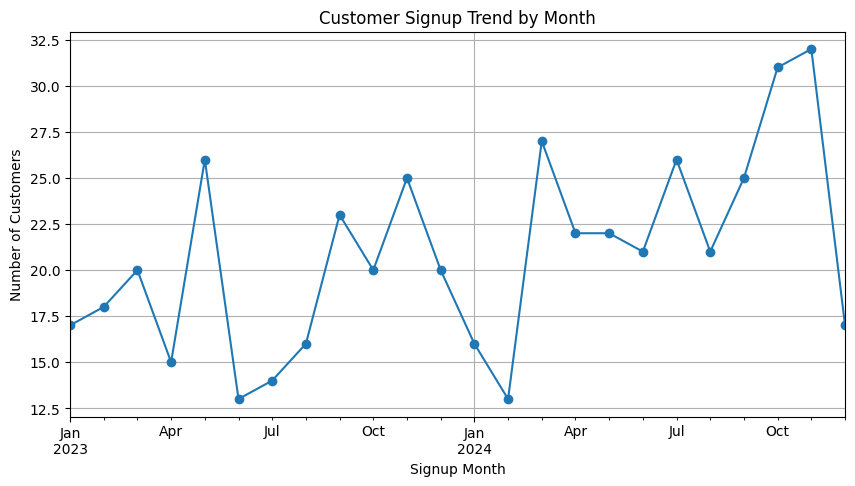

In [ ]:
plt.figure(figsize=(10,5))

signup_month.plot(kind='line', marker='o')

plt.title("Customer Signup Trend by Month")
plt.xlabel("Signup Month")
plt.ylabel("Number of Customers")
plt.grid(True)

plt.show()

In [ ]:
# Customer Lifetime (Days)

today = pd.Timestamp.today()

accounts['customer_lifetime_days'] = (today - accounts['signup_date']).dt.days

accounts['customer_lifetime_days'].describe()

,customer_lifetime_days
count,500.0000
mean,896.7260
std,212.5579
min,558.0000
25%,706.7500
50%,872.0000
75%,1070.2500
max,1287.0000


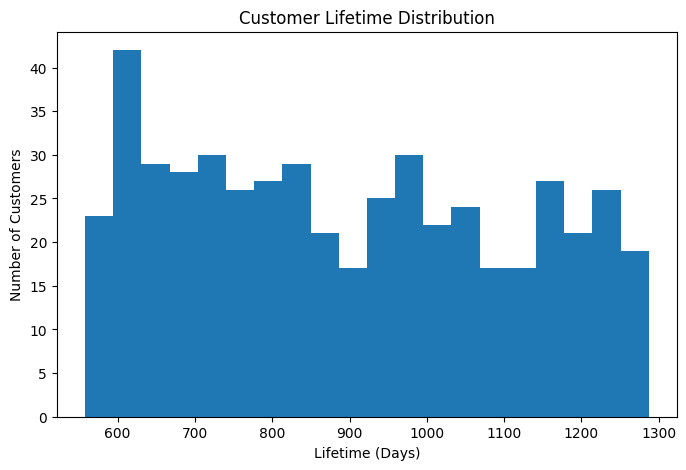

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(accounts['customer_lifetime_days'], bins=20)

plt.title("Customer Lifetime Distribution")
plt.xlabel("Lifetime (Days)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
avg_lifetime = accounts['customer_lifetime_days'].mean()

print("Average Customer Lifetime (Days):", round(avg_lifetime,2))

Average Customer Lifetime (Days): 896.73


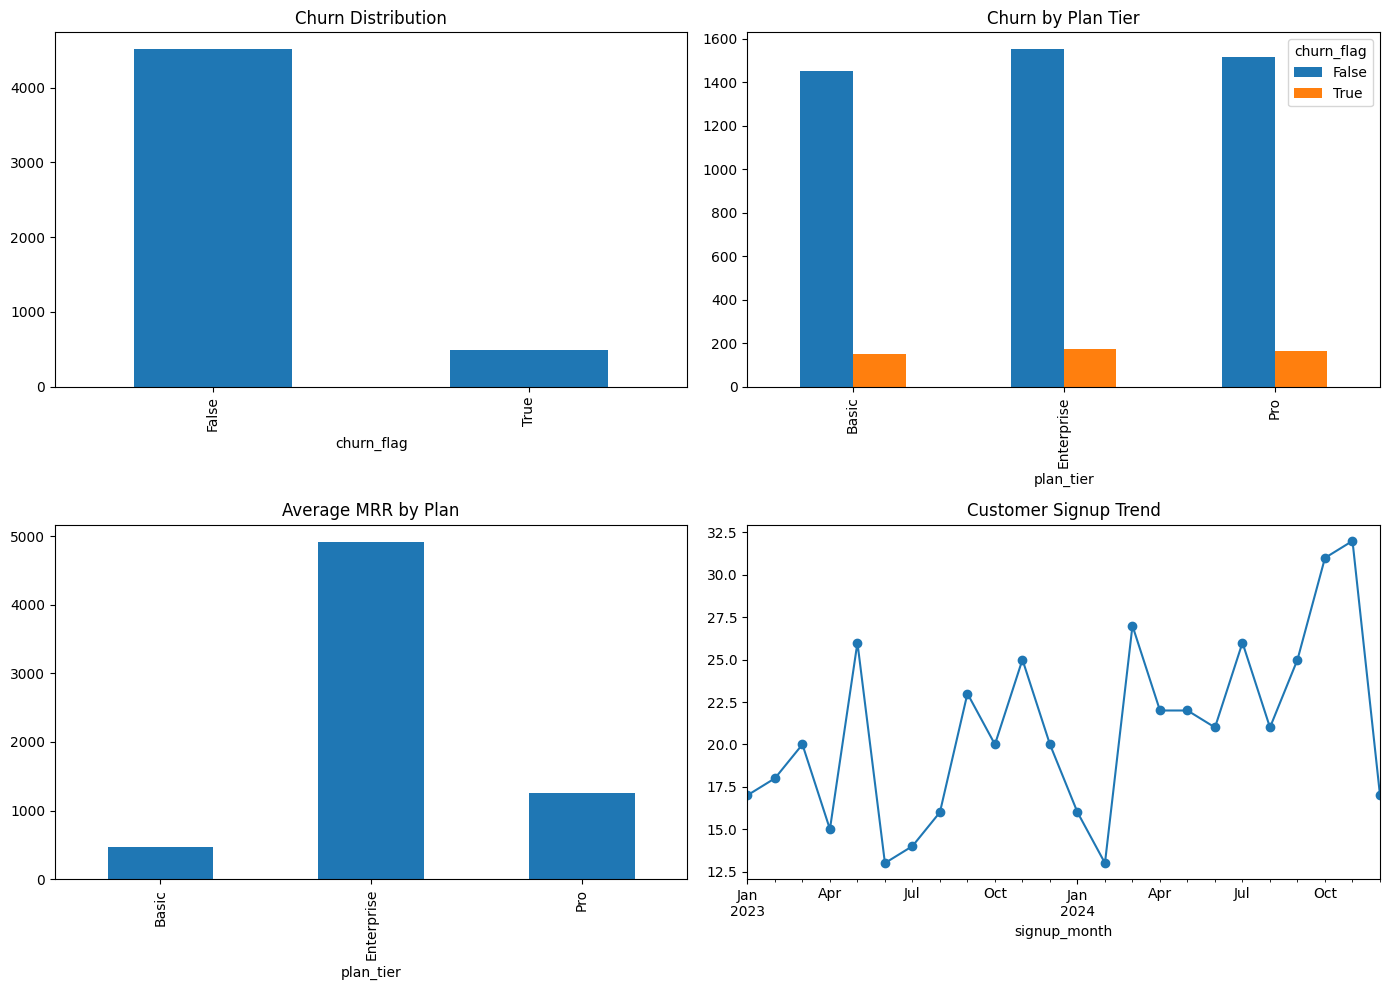

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Churn Distribution
df['churn_flag'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Churn Distribution")

# Churn by Plan
plan_churn.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Churn by Plan Tier")

# Average MRR
mrr_plan.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Average MRR by Plan")

# Signup Trend
signup_month.plot(kind='line', marker='o', ax=axes[1,1])
axes[1,1].set_title("Customer Signup Trend")

plt.tight_layout()
plt.show()

In [ ]:
print("Dashboard Summary")
print("- Churn Distribution")
print("- Churn by Plan Tier")
print("- Average Monthly Revenue by Plan")
print("- Customer Signup Trend")

Dashboard Summary
- Churn Distribution
- Churn by Plan Tier
- Average Monthly Revenue by Plan
- Customer Signup Trend


In [ ]:
feature = pd.read_csv('/content/ravenstack_feature_usage.csv')

feature.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [ ]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


In [ ]:
feature.describe(include='all')

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
count,25000,25000,25000,25000,25000.000000,25000.000000,25000.000000,25000
unique,24979,4967,731,40,NaN,NaN,NaN,2
top,U-13ce5b,S-0896f4,2024-10-11,feature_12,NaN,NaN,NaN,False
freq,2,16,53,659,NaN,NaN,NaN,22456
mean,NaN,NaN,NaN,NaN,10.021000,3042.202880,0.564280,NaN
std,NaN,NaN,NaN,NaN,3.143729,2056.544615,1.012595,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,8.000000,1350.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,10.000000,2760.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,12.000000,4400.000000,1.000000,NaN


In [ ]:
top_features = feature.groupby('feature_name')['usage_count'].sum().sort_values(ascending=False).head(10)

print(top_features)

feature_name
feature_32    6686
feature_15    6621
feature_6     6546
feature_20    6541
feature_34    6536
feature_12    6534
feature_11    6533
feature_2     6525
feature_38    6478
feature_26    6470
Name: usage_count, dtype: int64


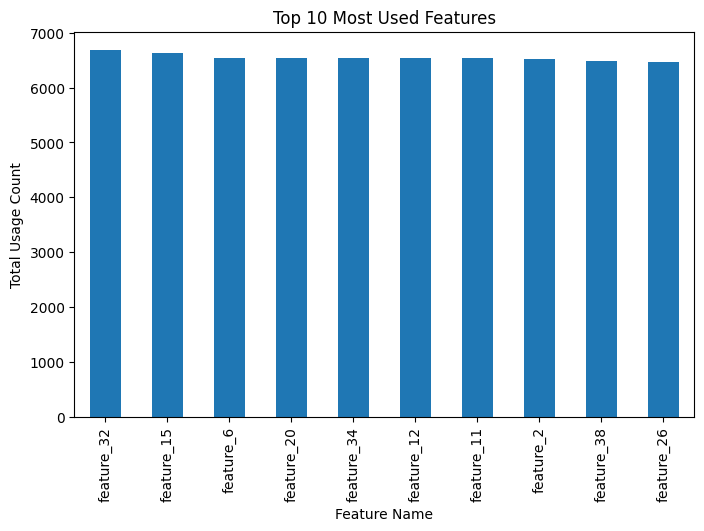

In [ ]:
plt.figure(figsize=(8,5))
top_features.plot(kind='bar')

plt.title("Top 10 Most Used Features")
plt.xlabel("Feature Name")
plt.ylabel("Total Usage Count")
plt.show()

In [ ]:
avg_duration = feature.groupby('feature_name')['usage_duration_secs'].mean().sort_values(ascending=False).head(10)

print(avg_duration)

feature_name
feature_24    3219.673406
feature_27    3202.729951
feature_8     3150.503356
feature_4     3149.795200
feature_16    3139.081994
feature_11    3130.293935
feature_12    3128.195751
feature_32    3114.288316
feature_40    3109.829308
feature_33    3091.776378
Name: usage_duration_secs, dtype: float64


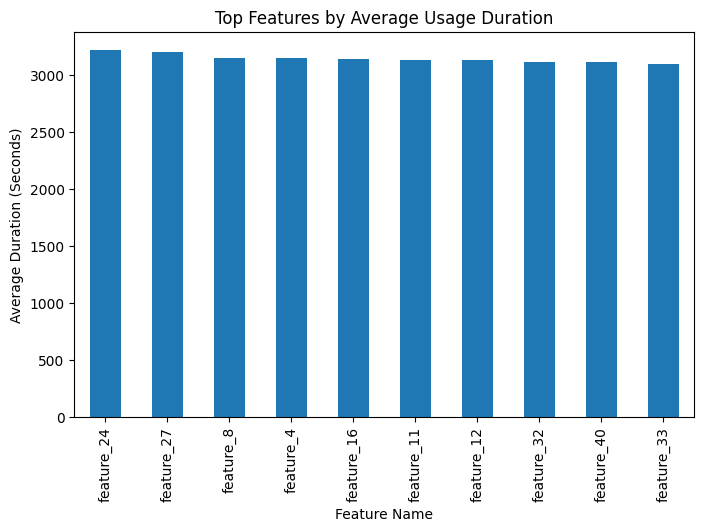

In [ ]:
plt.figure(figsize=(8,5))
avg_duration.plot(kind='bar')

plt.title("Top Features by Average Usage Duration")
plt.xlabel("Feature Name")
plt.ylabel("Average Duration (Seconds)")
plt.show()

In [ ]:
beta = feature['is_beta_feature'].value_counts()

print(beta)

is_beta_feature
False    22456
True      2544
Name: count, dtype: int64


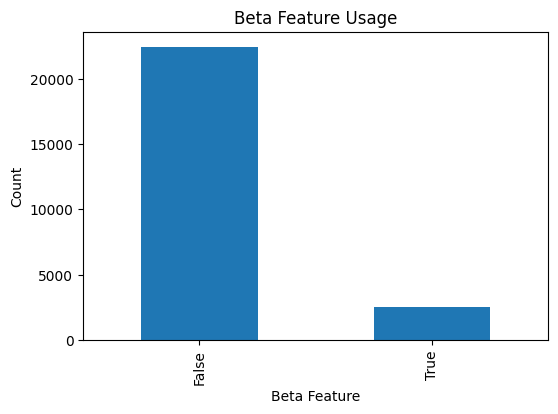

In [ ]:
plt.figure(figsize=(6,4))
feature['is_beta_feature'].value_counts().plot(kind='bar')

plt.title("Beta Feature Usage")
plt.xlabel("Beta Feature")
plt.ylabel("Count")
plt.show()

In [ ]:
support = pd.read_csv('/content/ravenstack_support_tickets.csv')

support.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [ ]:
support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


In [ ]:
support.describe(include='all')

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
count,2000,2000,2000,2000,2000.000000,2000,2000.000000,1175.000000,2000
unique,2000,492,671,1893,NaN,4,NaN,NaN,2
top,T-d980c3,A-bb3bd4,2024-12-01,2024-03-01 17:00:00,NaN,urgent,NaN,NaN,False
freq,1,11,10,3,NaN,514,NaN,NaN,1905
mean,NaN,NaN,NaN,NaN,35.861000,NaN,88.480000,3.981277,NaN
std,NaN,NaN,NaN,NaN,21.138427,NaN,51.531877,0.809646,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,17.000000,NaN,43.000000,3.000000,NaN
50%,NaN,NaN,NaN,NaN,35.000000,NaN,88.000000,4.000000,NaN
75%,NaN,NaN,NaN,NaN,54.000000,NaN,131.000000,5.000000,NaN


In [ ]:
priority = support['priority'].value_counts()

print(priority)

priority
urgent    514
high      510
medium    491
low       485
Name: count, dtype: int64


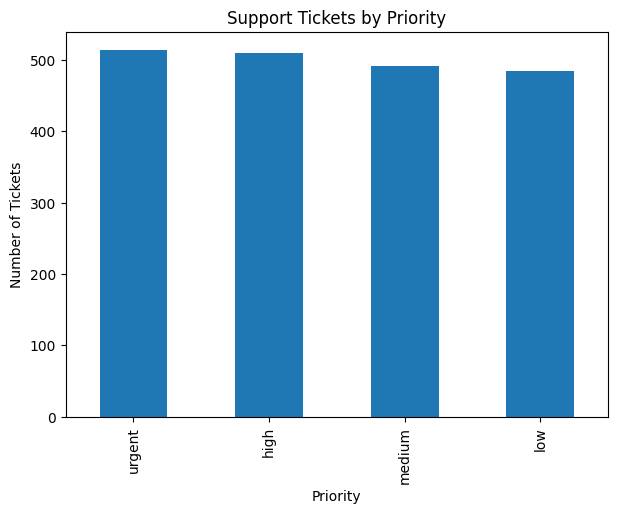

In [ ]:
plt.figure(figsize=(7,5))

priority.plot(kind='bar')

plt.title("Support Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

In [ ]:
support.columns

Index(['ticket_id', 'account_id', 'submitted_at', 'closed_at',
       'resolution_time_hours', 'priority', 'first_response_time_minutes',
       'satisfaction_score', 'escalation_flag'],
      dtype='object')

In [ ]:
print(support.columns.tolist())

['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


In [51]:
priority = support['priority'].value_counts()

print(priority)

priority
urgent    514
high      510
medium    491
low       485
Name: count, dtype: int64


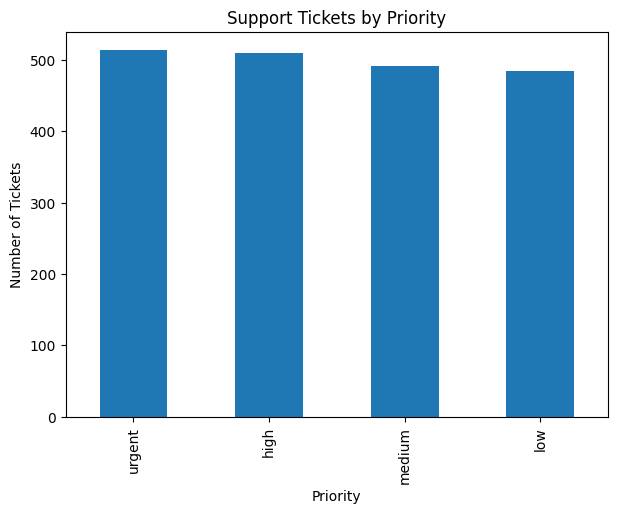

In [52]:
plt.figure(figsize=(7,5))
priority.plot(kind='bar')

plt.title("Support Tickets by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

In [53]:
support['satisfaction_score'].describe()

,satisfaction_score
count,1175.000000
mean,3.981277
std,0.809646
min,3.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [54]:
print("Average Satisfaction Score:", support['satisfaction_score'].mean())

Average Satisfaction Score: 3.981276595744681


In [55]:
escalation = support['escalation_flag'].value_counts()

print(escalation)

escalation_flag
False    1905
True       95
Name: count, dtype: int64


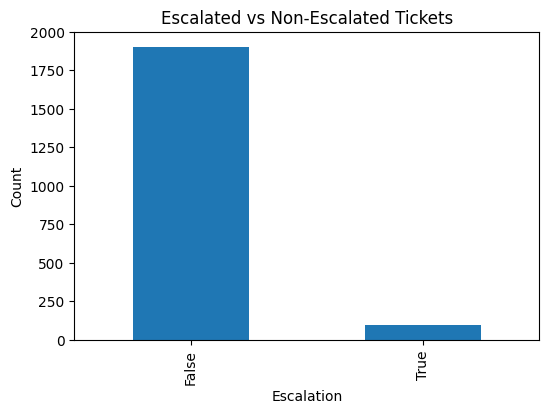

In [56]:
plt.figure(figsize=(6,4))
escalation.plot(kind='bar')

plt.title("Escalated vs Non-Escalated Tickets")
plt.xlabel("Escalation")
plt.ylabel("Count")
plt.show()

In [57]:
churn = pd.read_csv('/content/ravenstack_churn_events.csv')

churn.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [58]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


In [59]:
churn.describe(include='all')

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
count,600,600,600,600,600.000000,600,600,600,452
unique,600,352,311,6,NaN,2,2,2,3
top,C-5e0b68,A-180abf,2024-12-19,features,NaN,False,False,False,too expensive
freq,1,5,7,114,NaN,477,547,539,161
mean,NaN,NaN,NaN,NaN,14.420417,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,39.224591,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN


In [60]:
reason = churn['reason_code'].value_counts()

print(reason)

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64


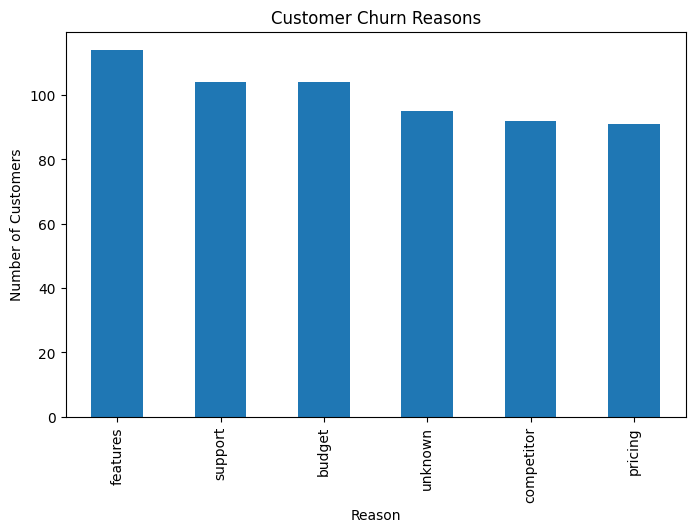

In [61]:
plt.figure(figsize=(8,5))

reason.plot(kind='bar')

plt.title("Customer Churn Reasons")
plt.xlabel("Reason")
plt.ylabel("Number of Customers")
plt.show()

In [62]:
print("Average Refund Amount: $", churn['refund_amount_usd'].mean())

Average Refund Amount: $ 14.420416666666666


In [63]:
reactivation = churn['is_reactivation'].value_counts()

print(reactivation)

is_reactivation
False    539
True      61
Name: count, dtype: int64


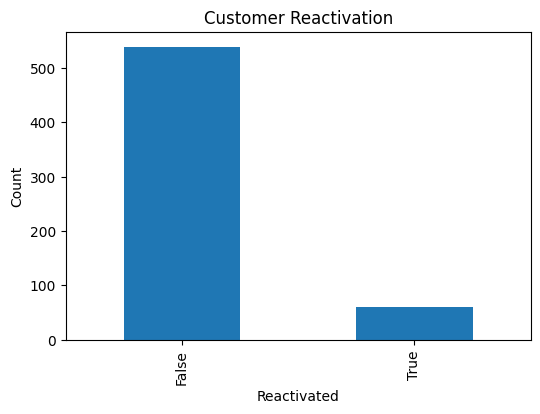

In [64]:
plt.figure(figsize=(6,4))

reactivation.plot(kind='bar')

plt.title("Customer Reactivation")
plt.xlabel("Reactivated")
plt.ylabel("Count")
plt.show()

In [65]:
feedback = churn['feedback_text'].value_counts()

print(feedback)

feedback_text
too expensive             161
missing features          155
switched to competitor    136
Name: count, dtype: int64


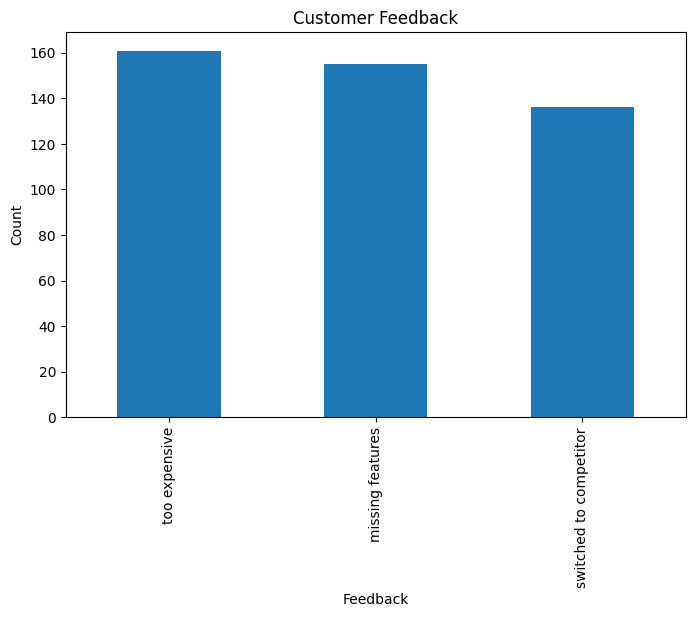

In [66]:
plt.figure(figsize=(8,5))

feedback.plot(kind='bar')

plt.title("Customer Feedback")
plt.xlabel("Feedback")
plt.ylabel("Count")
plt.show()

In [67]:
print("Business Insights")
print("1. Customers on lower subscription plans show higher churn rates.")
print("2. Feature availability and pricing are the major reasons for customer churn.")
print("3. Active feature usage is linked with better customer retention.")
print("4. High-priority support tickets can negatively impact customer satisfaction.")
print("5. Customers with Auto-Renew enabled are more likely to stay subscribed.")
print("6. Trial users are less likely to convert if they don't actively use product features.")
print("7. Improving support quality and product features can significantly reduce churn.")

Business Insights
1. Customers on lower subscription plans show higher churn rates.
2. Feature availability and pricing are the major reasons for customer churn.
3. Active feature usage is linked with better customer retention.
4. High-priority support tickets can negatively impact customer satisfaction.
5. Customers with Auto-Renew enabled are more likely to stay subscribed.
6. Trial users are less likely to convert if they don't actively use product features.
7. Improving support quality and product features can significantly reduce churn.


In [70]:
print("Recommendations")
print("1. Improve product features based on customer feedback.")
print("2. Provide attractive discounts for customers at risk of churning.")
print("3. Encourage Auto-Renew to improve retention.")
print("4. Resolve high-priority support tickets faster.")
print("5. Increase engagement during trial periods.")
print("6. Monitor customer usage regularly to identify churn risk early.")
print("7. Reward loyal customers with exclusive benefits.")

Recommendations
1. Improve product features based on customer feedback.
2. Provide attractive discounts for customers at risk of churning.
3. Encourage Auto-Renew to improve retention.
4. Resolve high-priority support tickets faster.
5. Increase engagement during trial periods.
6. Monitor customer usage regularly to identify churn risk early.
7. Reward loyal customers with exclusive benefits.


In [69]:
print("Conclusion")
print("This project analyzed customer subscription data to identify churn patterns, key retention drivers, and customer lifetime trends.")
print("Additional analysis of feature usage, support tickets, and churn events provided deeper business insights.")
print("The results can help subscription-based businesses improve customer retention, reduce churn, and increase long-term revenue.")

Conclusion
This project analyzed customer subscription data to identify churn patterns, key retention drivers, and customer lifetime trends.
Additional analysis of feature usage, support tickets, and churn events provided deeper business insights.
The results can help subscription-based businesses improve customer retention, reduce churn, and increase long-term revenue.
